In [4]:
import numpy as np

# Load the .npz file
data = np.load("/Users/chaechae/Desktop/FIU/mmShCola/data/selected/D6_0813_Day6S1_FullData_Results_merged/SAMMM.npz", allow_pickle=True)

# Print all keys
print("Keys in the file:", list(data.keys()))

# Print shapes of all arrays
for key in data:
    print(f"{key}: shape = {data[key].shape}")

Keys in the file: ['Mdiattenuations', 'nM', 'SHGZ', 'TPEFZ', 'M11s', 'Mdepols', 'Morientations', 'linrs', 'depth_selection_map', 'fSHGZ', 'fTPEFZ', 'fM11s', 'flinrs', 'fnM', 'fMdepols', 'fMdiattenuations', 'fMorientations', 'denoise_meta']
Mdiattenuations: shape = (501, 501)
nM: shape = (501, 501, 16)
SHGZ: shape = (501, 501)
TPEFZ: shape = (501, 501)
M11s: shape = (501, 501)
Mdepols: shape = (501, 501)
Morientations: shape = (501, 501)
linrs: shape = (501, 501)
depth_selection_map: shape = (501, 501)
fSHGZ: shape = (501, 501)
fTPEFZ: shape = (501, 501)
fM11s: shape = (501, 501)
flinrs: shape = (501, 501)
fnM: shape = (501, 501, 16)
fMdepols: shape = (501, 501)
fMdiattenuations: shape = (501, 501)
fMorientations: shape = (501, 501)
denoise_meta: shape = ()


In [5]:

import numpy as np

# Load the .npz file
data = np.load("/Volumes/ep_ssd/MPL_Data/muellerGestation/npz/Day6/mm_results_day6_1/TRIMMM.npz", allow_pickle=True)

# Print all keys
print("Keys in the file:", list(data.keys()))

# Print shapes of all arrays
for key in data:
    print(f"{key}: shape = {data[key].shape}")

Keys in the file: ['M11s', 'nM', 'MM_sample', 'Mdepols', 'Mdiattenuations', 'Morientations', 'linrs', 'dataset', 'original_filename', 'img_source', 'day', 'nM11s', 'M11_norm_info']
M11s: shape = (1079, 1279)
nM: shape = (1079, 1279, 16)
MM_sample: shape = (4, 4)
Mdepols: shape = (1079, 1279)
Mdiattenuations: shape = (1079, 1279)
Morientations: shape = (1079, 1279)
linrs: shape = (1079, 1279)
dataset: shape = ()
original_filename: shape = ()
img_source: shape = ()
day: shape = ()
nM11s: shape = (1079, 1279)
M11_norm_info: shape = ()


Available keys: ['M11s', 'nM', 'MM_sample', 'Mdepols', 'Mdiattenuations', 'Morientations', 'linrs', 'dataset', 'original_filename', 'img_source', 'day', 'nM11s', 'M11_norm_info']
Image size: 1079 x 1279
Center: (539, 639)

=== Detecting tissue ===
Initial mask: 361918 pixels
Relaxed mask: 455209 pixels
Final mask: 552961 pixels


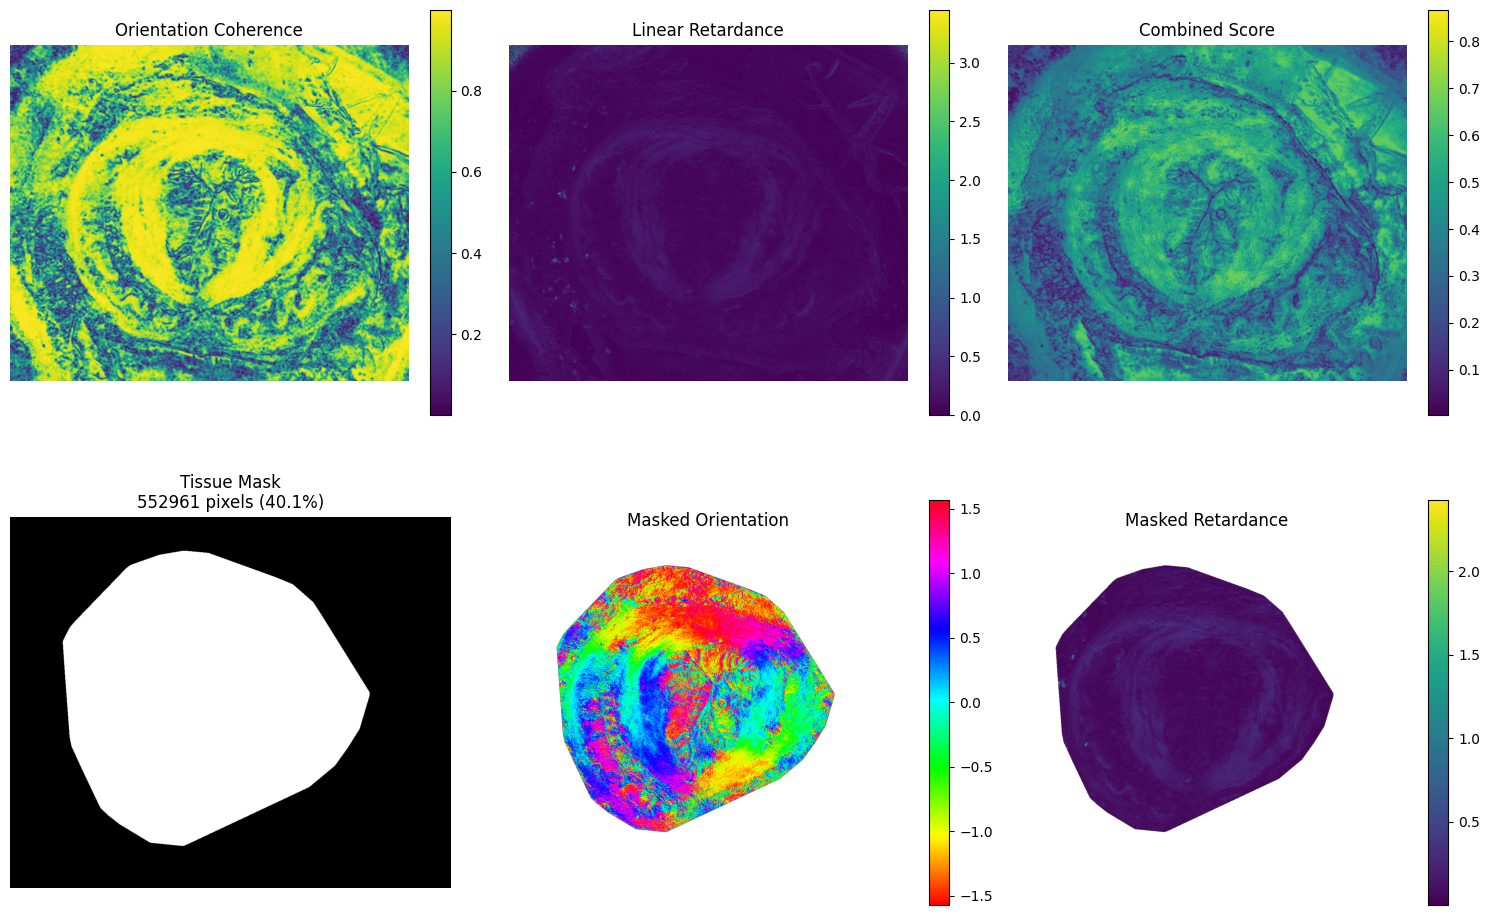


Linear Retardance (tissue only):
  Mean: 0.1114
  Std: 0.0707


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, label, binary_dilation, binary_erosion, binary_fill_holes, uniform_filter
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects, disk, convex_hull_image, binary_closing, remove_small_holes
from skimage.measure import regionprops

class TissueDetector:
    """
    Detect tissue regions in Mueller matrix polarimetry images.
    Handles thin sections with weak signals using orientation coherence.
    """
    
    def __init__(self, data_dict):
        """Initialize with Mueller matrix data from .npz file"""
        self.nM = data_dict.get('nM', None)
        self.M11 = data_dict.get('M11s', None)
        self.depol = data_dict.get('Mdepols', None)
        self.linr = data_dict.get('linrs', None)
        self.diatt = data_dict.get('Mdiattenuations', None)
        self.orient = data_dict.get('Morientations', None)
        
        # Get image dimensions
        if self.M11 is not None:
            self.height, self.width = self.M11.shape
        elif self.orient is not None:
            self.height, self.width = self.orient.shape
        elif self.linr is not None:
            self.height, self.width = self.linr.shape
        else:
            raise ValueError("No valid data found")
        
        self.center = (self.height // 2, self.width // 2)
    
    def compute_orientation_coherence(self, window_size=7):
        """
        Compute local orientation coherence.
        Tissue has structured orientation, background is random.
        
        Returns: coherence map (0=random, 1=coherent)
        """
        if self.orient is None:
            return None
        
        # Convert to complex for circular statistics
        orient_complex = np.exp(2j * self.orient)
        
        # Local mean of complex orientation
        mean_real = uniform_filter(np.real(orient_complex), size=window_size)
        mean_imag = uniform_filter(np.imag(orient_complex), size=window_size)
        
        # Coherence is magnitude of mean vector
        coherence = np.sqrt(mean_real**2 + mean_imag**2)
        
        return coherence
    
    def detect_tissue_multifeature(self, use_orientation=True, use_retardance=True, 
                                   use_intensity=True):
        """
        Detect tissue using multiple polarimetric features.
        
        Returns: 
            - initial_mask: rough tissue detection
            - feature_scores: dict of individual feature maps
        """
        feature_scores = {}
        combined_score = np.zeros((self.height, self.width))
        n_features = 0
        
        # Feature 1: Orientation coherence
        if use_orientation and self.orient is not None:
            coherence = self.compute_orientation_coherence(window_size=7)
            coherence_norm = (coherence - np.nanmin(coherence)) / (np.nanmax(coherence) - np.nanmin(coherence))
            feature_scores['orientation_coherence'] = coherence
            combined_score += coherence_norm
            n_features += 1
        
        # Feature 2: Retardance
        if use_retardance and self.linr is not None:
            linr_norm = (self.linr - np.nanmin(self.linr)) / (np.nanmax(self.linr) - np.nanmin(self.linr))
            feature_scores['retardance'] = self.linr
            combined_score += linr_norm
            n_features += 1
        
        # Feature 3: Intensity
        if use_intensity and self.M11 is not None:
            m11_norm = (self.M11 - np.nanmin(self.M11)) / (np.nanmax(self.M11) - np.nanmin(self.M11))
            feature_scores['intensity'] = self.M11
            combined_score += m11_norm
            n_features += 1
        
        # Normalize combined score
        if n_features > 0:
            combined_score = combined_score / n_features
        
        feature_scores['combined_score'] = combined_score
        
        # Threshold using Otsu
        try:
            threshold = threshold_otsu(combined_score)
        except:
            threshold = np.percentile(combined_score, 50)
        
        initial_mask = combined_score > threshold
        
        # Keep only largest component
        labeled = label(initial_mask)[0]
        if labeled.max() > 0:
            regions = regionprops(labeled)
            largest = max(regions, key=lambda r: r.area)
            initial_mask = labeled == largest.label
        
        return initial_mask, feature_scores
    
    def create_continuous_mask(self, initial_mask, method='convex_hull', dilation_size=15):
        """
        Create continuous mask by filling holes and connecting regions.
        
        Parameters:
            method: 'convex_hull', 'morphological', or 'fill_holes'
            dilation_size: pixels to dilate (for morphological method)
        
        Returns: continuous mask without gaps
        """
        # Get largest component
        labeled = label(initial_mask)[0]
        if labeled.max() == 0:
            return initial_mask
        
        regions = regionprops(labeled)
        largest = max(regions, key=lambda r: r.area)
        largest_mask = labeled == largest.label
        
        if method == 'convex_hull':
            # Smoothest boundary - connects everything
            continuous_mask = convex_hull_image(largest_mask)
            
        elif method == 'morphological':
            # Bridge gaps while preserving shape
            continuous_mask = binary_closing(largest_mask, disk(dilation_size))
            continuous_mask = binary_fill_holes(continuous_mask)
            
        elif method == 'fill_holes':
            # Just fill internal holes
            continuous_mask = binary_fill_holes(largest_mask)
            continuous_mask = remove_small_holes(continuous_mask, area_threshold=100)
        else:
            continuous_mask = largest_mask
        
        return continuous_mask
    
    def apply_mask(self, mask):
        """Apply mask to all parameters"""
        masked_data = {}
        
        if self.M11 is not None:
            masked_data['M11'] = np.where(mask, self.M11, np.nan)
        
        if self.depol is not None:
            masked_data['depol'] = np.where(mask, self.depol, np.nan)
        
        if self.linr is not None:
            masked_data['linr'] = np.where(mask, self.linr, np.nan)
        
        if self.diatt is not None:
            masked_data['diatt'] = np.where(mask, self.diatt, np.nan)
        
        if self.orient is not None:
            masked_data['orient'] = np.where(mask, self.orient, np.nan)
        
        if self.nM is not None:
            if self.nM.ndim == 4:  # (H, W, 4, 4)
                mask_4d = mask[..., np.newaxis, np.newaxis]
                masked_data['nM'] = np.where(mask_4d, self.nM, np.nan)
            elif self.nM.ndim == 3:  # (H, W, 16)
                mask_3d = mask[..., np.newaxis]
                masked_data['nM'] = np.where(mask_3d, self.nM, np.nan)
        
        return masked_data
    
    def visualize(self, mask, feature_scores):
        """Visualize detection results"""
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        # Row 1: Features
        if 'orientation_coherence' in feature_scores:
            im = axes[0, 0].imshow(feature_scores['orientation_coherence'], cmap='viridis')
            axes[0, 0].set_title('Orientation Coherence')
            axes[0, 0].axis('off')
            plt.colorbar(im, ax=axes[0, 0], fraction=0.046)
        
        if 'retardance' in feature_scores:
            im = axes[0, 1].imshow(feature_scores['retardance'], cmap='viridis')
            axes[0, 1].set_title('Linear Retardance')
            axes[0, 1].axis('off')
            plt.colorbar(im, ax=axes[0, 1], fraction=0.046)
        
        im = axes[0, 2].imshow(feature_scores['combined_score'], cmap='viridis')
        axes[0, 2].set_title('Combined Score')
        axes[0, 2].axis('off')
        plt.colorbar(im, ax=axes[0, 2], fraction=0.046)
        
        # Row 2: Mask results
        axes[1, 0].imshow(mask, cmap='gray')
        axes[1, 0].set_title(f'Tissue Mask\n{np.sum(mask)} pixels ({100*np.sum(mask)/mask.size:.1f}%)')
        axes[1, 0].axis('off')
        
        # Masked orientation
        if self.orient is not None:
            masked_orient = np.where(mask, self.orient, np.nan)
            im = axes[1, 1].imshow(masked_orient, cmap='hsv')
            axes[1, 1].set_title('Masked Orientation')
            axes[1, 1].axis('off')
            plt.colorbar(im, ax=axes[1, 1], fraction=0.046)
        
        # Masked retardance
        if self.linr is not None:
            masked_linr = np.where(mask, self.linr, np.nan)
            im = axes[1, 2].imshow(masked_linr, cmap='viridis')
            axes[1, 2].set_title('Masked Retardance')
            axes[1, 2].axis('off')
            plt.colorbar(im, ax=axes[1, 2], fraction=0.046)
        
        plt.tight_layout()
        return fig


# ==================== USAGE ====================

# Load data
data = np.load("/Volumes/ep_ssd/MPL_Data/muellerGestation/npz/Day6/mm_results_day6_1/TRIMMM.npz", 
               allow_pickle=True)

print("Available keys:", list(data.keys()))

# Initialize detector
detector = TissueDetector(data)
print(f"Image size: {detector.height} x {detector.width}")
print(f"Center: {detector.center}")

# Step 1: Initial detection
print("\n=== Detecting tissue ===")
initial_mask, features = detector.detect_tissue_multifeature(
    use_orientation=True,
    use_retardance=True,
    use_intensity=True
)

# Step 2: Make it less strict (expand)
relaxed_mask = binary_dilation(initial_mask, disk(5))

# Step 3: Create continuous mask (no holes/gaps)
final_mask = detector.create_continuous_mask(
    relaxed_mask,
    method='convex_hull',  # Try: 'convex_hull', 'morphological', 'fill_holes'
    dilation_size=15
)

print(f"Initial mask: {np.sum(initial_mask)} pixels")
print(f"Relaxed mask: {np.sum(relaxed_mask)} pixels")
print(f"Final mask: {np.sum(final_mask)} pixels")

# Apply mask
masked_data = detector.apply_mask(final_mask)

# Visualize
fig = detector.visualize(final_mask, features)
plt.show()

# Statistics
if 'linr' in masked_data:
    tissue_lr = masked_data['linr'][np.isfinite(masked_data['linr'])]
    print(f"\nLinear Retardance (tissue only):")
    print(f"  Mean: {np.mean(tissue_lr):.4f}")
    print(f"  Std: {np.std(tissue_lr):.4f}")